### Google Colab Connection

In [6]:
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

BASE_PATH = "/content/drive/MyDrive/Brick_Detection/"

REPO_DIR = os.path.join(BASE_PATH, "repo")

if not os.path.exists(REPO_DIR):
    print("Cloning repository...")
    !git clone https://github.com/Crightub/lego-brick-detection.git {REPO_DIR}
else:
    print("Repo already exists, pulling latest changes...")
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())

# 3. Install dependencies
print("Installing requirements...")
!pip install -r requirements.txt -q
print("Done!")


KeyboardInterrupt: 

### Local Execution

In [ ]:
BASE_PATH = os.getcwd()

In [5]:
import os
print(os.listdir(BASE_PATH))

NameError: name 'BASE_PATH' is not defined

In [ ]:
import shutil
from torchvision.utils import draw_bounding_boxes
from b200_lego_dataset import load_val_set
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import csv
import cv2
from tqdm import tqdm
import xml.etree.ElementTree as ET

### Dataset Preparation


In [ ]:
image_path = os.path.join(BASE_PATH, "B200_Lego_Dataset/images")
annotation_path = os.path.join(BASE_PATH, "B200_Lego_Dataset/annotations")
# label_path = os.path.join(BASE_PATH, "data/labels")

In [ ]:
val_data = load_val_set()

Visualization of data points

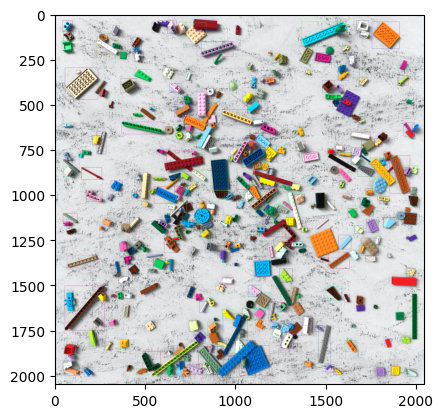

In [38]:
sample = val_data[0]
img, target = sample
boxes = target['boxes'].long()

output_image = draw_bounding_boxes(img, boxes)
plt.imshow(output_image.permute(1, 2, 0))

### Scale Down of Pictures

The original picture have a size of 2000x2000 which results in a large data size.
We scale down the pictures to a size of 640x640 for more efficient training.

In [ ]:
output_adjusted_base_path = os.path.join(BASE_PATH, "data/adjusted_dataset")
output_adjusted_image_path = os.path.join(output_adjusted_base_path, "images")
output_adjusted_annotation_path = os.path.join(output_adjusted_base_path, "annotations")

os.makedirs(output_adjusted_base_path, exist_ok=True)
os.makedirs(output_adjusted_image_path, exist_ok=True)
os.makedirs(output_adjusted_annotation_path, exist_ok=True)

TARGET_SIZE = 640

def downscale_dataset():
    image_files = [f for f in os.listdir(image_path) if f.lower().endswith(('.jpg', '.png'))]

    for img_name in tqdm(image_files):
        img = cv2.imread(os.path.join(image_path, img_name))
        h_orig, w_orig = img.shape[:2]

        scale_x = TARGET_SIZE / w_orig
        scale_y = TARGET_SIZE / h_orig

        img_resized = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))

        xml_name = img_name.rsplit('.', 1)[0] + '.xml'
        tree = ET.parse(os.path.join(annotation_path, xml_name))
        root = tree.getroot()

        for obj in root.findall('object'):
            bbox = obj.find('bndbox')
            xmin = float(bbox.find('xmin').text) * scale_x
            ymin = float(bbox.find('ymin').text) * scale_y
            xmax = float(bbox.find('xmax').text) * scale_x
            ymax = float(bbox.find('ymax').text) * scale_y

            # CRITICAL: Ensure no zero-area boxes
            if (xmax - xmin) < 1.0: xmax += 1.0
            if (ymax - ymin) < 1.0: ymax += 1.0

            bbox.find('xmin').text = str(round(xmin, 2))
            bbox.find('ymin').text = str(round(ymin, 2))
            bbox.find('xmax').text = str(round(xmax, 2))
            bbox.find('ymax').text = str(round(ymax, 2))

        cv2.imwrite(os.path.join(output_adjusted_image_path, img_name), img_resized)
        tree.write(os.path.join(output_adjusted_annotation_path, xml_name))

downscale_dataset()

In [ ]:
if not os.path.exists(output_adjusted_base_path):
    downscale_dataset()
else:
    print('Preprocessed data found.')

### Train, Val, Test Split

Generate a train, val, test split with percentages (0.7, 0.15, 0.15) resulting in samples size of (1400, 300, 300).
To reuse the same split later and compare different models, store the samples in the subdirectory /train, /val, /test.

In [ ]:
train_destination = os.getcwd() + "/data/train"
val_destination = os.getcwd() + "/data/val"
test_destination = os.getcwd() + "/data/test"

def move_files(files, source, destination):
    os.makedirs(destination, exist_ok=True)
    for f in files:
        shutil.copy(os.path.join(source, f), os.path.join(destination, f))

def generate_train_val_test_split():
    images = sorted(os.listdir(output_adjusted_image_path))
    annotations = sorted(os.listdir(output_adjusted_annotation_path))

    images_train, images_temp, annotations_train, annotations_temp = train_test_split(images, annotations, train_size=0.7,
                                                                                      test_size=0.3, random_state=42)
    images_val, images_test, annotations_val, annotations_test = train_test_split(images_temp, annotations_temp,
                                                                                  train_size=0.5, test_size=0.5,
                                                                                  random_state=42)

    move_files(images_train, output_adjusted_image_path, os.path.join(train_destination, 'images'))
    move_files(annotations_train, output_adjusted_annotation_path, os.path.join(train_destination, 'annotations'))

    move_files(images_val, output_adjusted_image_path, os.path.join(val_destination, 'images'))
    move_files(annotations_val, output_adjusted_annotation_path, os.path.join(val_destination, 'annotations'))

    move_files(images_test, output_adjusted_image_path, os.path.join(test_destination, 'images'))
    move_files(annotations_test, output_adjusted_annotation_path, os.path.join(test_destination, 'annotations'))

In [ ]:
if not os.path.exists(train_destination):
    generate_train_val_test_split()
else:
    print('Train/Val/Test split data found.')

### Create Label Mapping

Object detection models expect labels starting from 0,...,m with 0 representing the background.
Create a mapping from the lego brick id to a label from {1,...,m} and store it in a csv file.
The dataset while later use this to identify the number of labels and convert the brick id in the annotation to a label.

In [ ]:
labels_path = os.path.join(BASE_PATH, 'labels_map')
def generate_labels_map():
    labels_map = {}
    label_counter = 1
    for file in os.listdir(annotation_path):
        tree = ET.parse(os.path.join(annotation_path, file))
        root = tree.getroot()
        for obj in root.iter('object'):
            label = obj.find('name').text
            if label not in labels_map and label_counter < 20:
                labels_map[label] = label_counter
                label_counter += 1

    with open(labels_path, "w", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(labels_map.items())

In [ ]:
if not os.path.exists(labels_path):
    generate_labels_map()
else:
    print('Labels map data found.')